## 函数拟合实验说明

### 1. 函数定义
选择目标函数 $f(x) = x \cdot \sin(x)$

### 2. 数据采集
在 $[-7, 7]$ 区间内随机采样3000个点，添加高斯噪声后按6:2:2比例划分为训练集、验证集和测试集。

### 3. 模型描述
采用两层ReLU神经网络，结构为：输入层(1) → 隐藏层(128) + ReLU → 输出层(1)，使用Adam优化器和MSE损失函数进行训练。

本实验采用两种实现方式：

PyTorch框架实现：使用内置的Adam优化器和自动微分

NumPy手工实现：从零实现前向传播、反向传播、Adam优化器

### 4. 拟合效果
| 模型 | 测试集MSE | R²分数 | 最佳验证损失 |
|:-----|----------:|--------:|-------------:|
| PyTorch (Adam) | 0.025874 | 0.9951 | 0.024148 |
| NumPy (Adam) | 0.025027 | 0.9954 | 0.025499 |

两个模型的R²分数均达到0.99以上，表明模型能够解释99.5%以上的数据方差，拟合效果优秀

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 设置随机种子，保证结果可重复
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


### 目标函数 $f(x) = x \cdot \sin(x)$

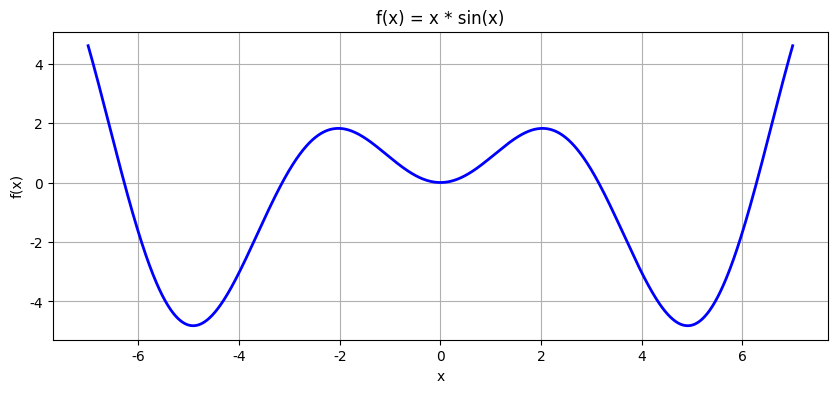

x范围: [-7.0, 7.0]
y范围: [-4.814, 4.599]


In [3]:
def target_function(x):
    return x * np.sin(x) 

x_test = np.linspace(-7, 7, 1000)
y_test = target_function(x_test)

plt.figure(figsize=(10, 4))
plt.plot(x_test, y_test, 'b-', linewidth=2)
plt.title('f(x) = x * sin(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()

print(f"x范围: [{x_test.min():.1f}, {x_test.max():.1f}]")
print(f"y范围: [{y_test.min():.3f}, {y_test.max():.3f}]")

### 数据采集

总样本数: 3000
训练集: 1800 个样本 (60.0%)
验证集: 600 个样本 (20.0%)
测试集: 600 个样本 (20.0%)
x范围: [-7.00, 6.98]
y范围: [-5.05, 4.69]
噪声水平: 0.1 (标准差)


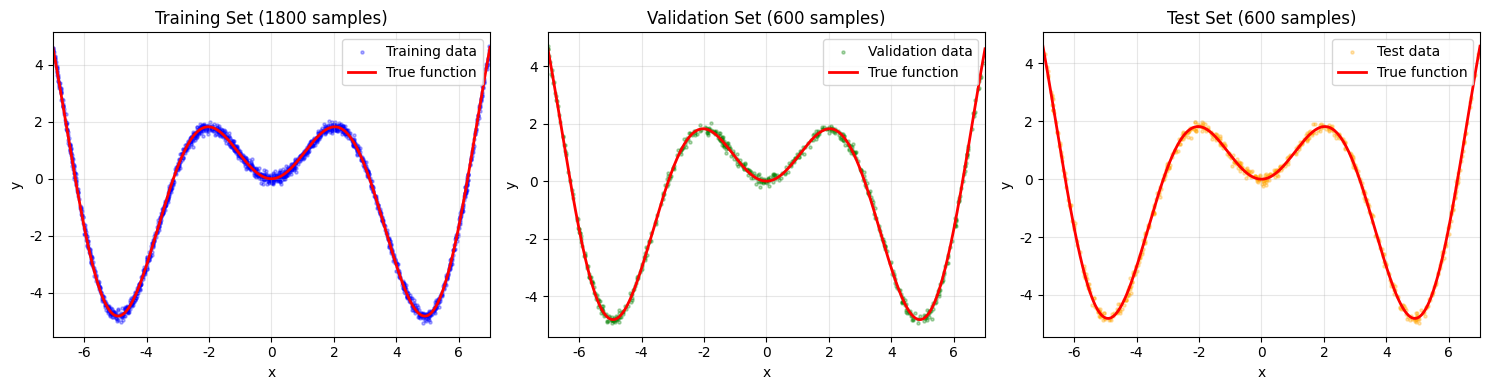

In [5]:
def generate_data(n_samples=3000, noise_level=0.1, x_range=(-7, 7)):
    """
    生成训练数据
    
    参数:
        n_samples: 总样本数
        noise_level: 噪声水平（标准差），添加少量噪声使问题更真实
        x_range: x的取值范围
    
    返回:
        X: 输入特征，形状 (n_samples, 1)
        y: 目标值，形状 (n_samples, 1)
    """
    # 在指定范围内均匀采样
    X = np.random.uniform(x_range[0], x_range[1], n_samples).reshape(-1, 1)    
    # 计算目标函数值
    y = target_function(X).reshape(-1, 1)    
    # 添加高斯噪声（使问题更接近实际情况）
    y += np.random.normal(0, noise_level, y.shape)    
    return X, y

X, y = generate_data(n_samples=3000, noise_level=0.1, x_range=(-7, 7))

# 划分数据集：60%训练，20%验证，20%测试
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"总样本数: {len(X)}")
print(f"训练集: {X_train.shape[0]} 个样本 ({len(X_train)/len(X)*100:.1f}%)")
print(f"验证集: {X_val.shape[0]} 个样本 ({len(X_val)/len(X)*100:.1f}%)")
print(f"测试集: {X_test.shape[0]} 个样本 ({len(X_test)/len(X)*100:.1f}%)")
print(f"x范围: [{X.min():.2f}, {X.max():.2f}]")
print(f"y范围: [{y.min():.2f}, {y.max():.2f}]")
print(f"噪声水平: 0.1 (标准差)")

# 可视化数据分布
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 训练集
axes[0].scatter(X_train, y_train, alpha=0.3, s=5, c='blue', label='Training data')
axes[0].plot(x_test, target_function(x_test), 'r-', linewidth=2, label='True function')
axes[0].set_title(f'Training Set ({len(X_train)} samples)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xlim(-7, 7)

# 验证集
axes[1].scatter(X_val, y_val, alpha=0.3, s=5, c='green', label='Validation data')
axes[1].plot(x_test, target_function(x_test), 'r-', linewidth=2, label='True function')
axes[1].set_title(f'Validation Set ({len(X_val)} samples)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xlim(-7, 7)

# 测试集
axes[2].scatter(X_test, y_test, alpha=0.3, s=5, c='orange', label='Test data')
axes[2].plot(x_test, target_function(x_test), 'r-', linewidth=2, label='True function')
axes[2].set_title(f'Test Set ({len(X_test)} samples)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_xlim(-7, 7)

plt.tight_layout()
plt.show()


### PyTorch模型

In [ ]:
class TwoLayerReLU_PyTorch(nn.Module):
    """
    两层ReLU神经网络（PyTorch实现）    
    结构:
        输入层(1) -> 线性层(1→hidden_size) -> ReLU -> 线性层(hidden_size→1)    
    参数:
        hidden_size: 隐藏层神经元数量
    """
    def __init__(self, hidden_size=128):
        super(TwoLayerReLU_PyTorch, self).__init__()        
        # 第一层：线性变换
        self.fc1 = nn.Linear(1, hidden_size)        
        # ReLU激活函数
        self.relu = nn.ReLU()        
        # 第二层：线性变换得到输出
        self.fc2 = nn.Linear(hidden_size, 1)        
        # 权重初始化（Xavier初始化有助于训练）
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)
    
    def forward(self, x):
        """
        前向传播        
        参数:
            x: 输入张量 [batch_size, 1]        
        返回:
            预测值 [batch_size, 1]
        """
        x_fc1 = self.fc1(x)
        x_relu = self.relu(x_fc1)
        x_fc2 = self.fc2(x_relu)
        return x_fc2

# 创建PyTorch模型
pytorch_model = TwoLayerReLU_PyTorch(hidden_size=128).to(device)
print(f"PyTorch模型结构:\n{pytorch_model}")
total_params = sum(p.numel() for p in pytorch_model.parameters())
print(f"总参数量: {total_params}")

PyTorch模型结构:
TwoLayerReLU_PyTorch(
  (fc1): Linear(in_features=1, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
总参数量: 385


In [8]:
def create_pytorch_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64):
    """
    创建PyTorch数据加载器    
    参数:
        X_train, y_train: 训练数据
        X_val, y_val: 验证数据
        X_test, y_test: 测试数据
        batch_size: 批次大小
    """
    # 转换为PyTorch张量
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.FloatTensor(y_val).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)
    
    # 创建TensorDataset
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)
    
    # 创建DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

# 创建数据加载器
batch_size = 64
train_loader, val_loader, test_loader = create_pytorch_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test, batch_size
)

# 损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20
)

print("PyTorch训练配置:")
print(f"损失函数: MSE")
print(f"优化器: Adam (lr=0.001)")
print(f"批次大小: {batch_size}")

PyTorch训练配置:
损失函数: MSE
优化器: Adam (lr=0.001)
批次大小: 64


In [10]:
def train_epoch_pytorch(model, train_loader, criterion, optimizer):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    for X_batch, y_batch in train_loader:
        # 前向传播
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate_pytorch(model, val_loader, criterion):
    """验证模型"""
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

# 训练循环
num_epochs = 300
train_losses_pytorch = []
val_losses_pytorch = []
best_val_loss = float('inf')

print("开始PyTorch模型训练...")
for epoch in range(num_epochs):
    # 训练
    train_loss = train_epoch_pytorch(pytorch_model, train_loader, criterion, optimizer)
    train_losses_pytorch.append(train_loss)
    
    # 验证
    val_loss = validate_pytorch(pytorch_model, val_loader, criterion)
    val_losses_pytorch.append(val_loss)
    
    # 学习率调度
    scheduler.step(val_loss)
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pytorch_model.state_dict(), 'best_pytorch_model.pth')
    
    # 打印进度
    if (epoch + 1) % 30 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}, '
              f'LR: {current_lr:.6f}')

print("PyTorch模型训练完成！")

开始PyTorch模型训练...
Epoch [30/300], Train Loss: 0.275566, Val Loss: 0.276045, LR: 0.001000
Epoch [60/300], Train Loss: 0.176628, Val Loss: 0.162759, LR: 0.001000
Epoch [90/300], Train Loss: 0.113001, Val Loss: 0.100395, LR: 0.001000
Epoch [120/300], Train Loss: 0.075342, Val Loss: 0.065915, LR: 0.001000
Epoch [150/300], Train Loss: 0.052756, Val Loss: 0.048610, LR: 0.001000
Epoch [180/300], Train Loss: 0.041323, Val Loss: 0.037660, LR: 0.001000
Epoch [210/300], Train Loss: 0.032366, Val Loss: 0.031156, LR: 0.001000
Epoch [240/300], Train Loss: 0.028424, Val Loss: 0.029506, LR: 0.001000
Epoch [270/300], Train Loss: 0.027965, Val Loss: 0.038036, LR: 0.001000
Epoch [300/300], Train Loss: 0.030296, Val Loss: 0.025140, LR: 0.001000
PyTorch模型训练完成！


PyTorch模型测试结果:
测试集MSE损失: 0.025874
R²分数: 0.9951


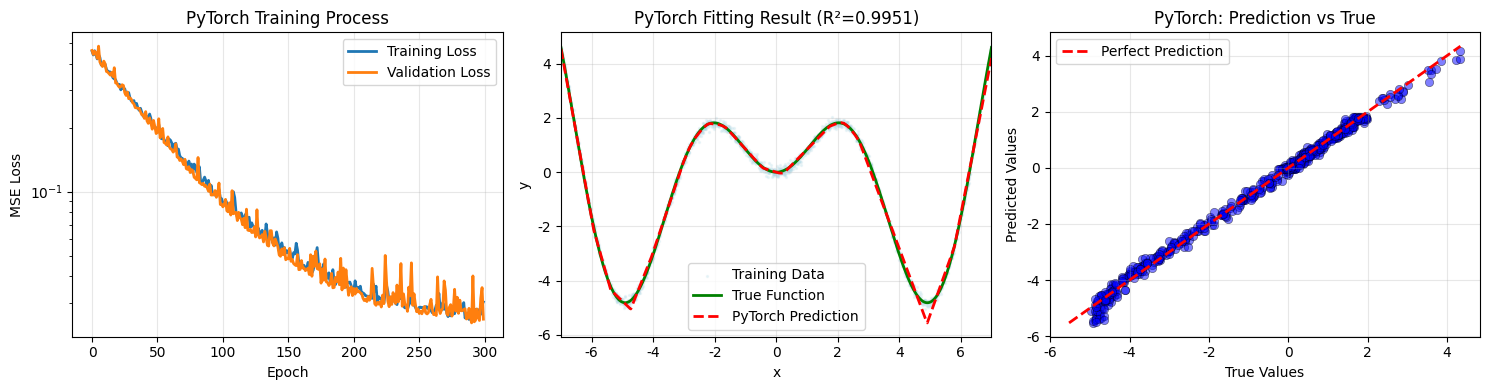

PyTorch模型训练完成！
最佳验证损失: 0.024148
最终测试损失: 0.025874
R²分数: 0.9951


In [ ]:
# 加载最佳模型
pytorch_model.load_state_dict(torch.load('best_pytorch_model.pth'))

# 测试集评估
pytorch_model.eval()
test_loss = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = pytorch_model(X_batch)
        test_loss += criterion(y_pred, y_batch).item()
test_loss /= len(test_loader)

X_test_tensor = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    y_pred_pytorch = pytorch_model(X_test_tensor).cpu().numpy()

# 计算R²分数
y_test_mean = np.mean(y_test)
ss_res = np.sum((y_test - y_pred_pytorch) ** 2)
ss_tot = np.sum((y_test - y_test_mean) ** 2)
r2_pytorch = 1 - (ss_res / ss_tot)

print(f"PyTorch模型测试结果:")
print(f"测试集MSE损失: {test_loss:.6f}")
print(f"R²分数: {r2_pytorch:.4f}")

x_eval = np.linspace(-7, 7, 1000).reshape(-1, 1)
x_eval_tensor = torch.FloatTensor(x_eval).to(device)
with torch.no_grad():
    y_eval_pred_pytorch = pytorch_model(x_eval_tensor).cpu().numpy()
y_eval_true = target_function(x_eval)

# 可视化PyTorch模型拟合效果
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 子图1：训练损失曲线
axes[0].plot(train_losses_pytorch, label='Training Loss', linewidth=2)
axes[0].plot(val_losses_pytorch, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('PyTorch Training Process')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# 子图2：拟合效果
axes[1].scatter(X_train, y_train, alpha=0.2, s=2, c='lightblue', label='Training Data')
axes[1].plot(x_eval, y_eval_true, 'g-', linewidth=2, label='True Function')
axes[1].plot(x_eval, y_eval_pred_pytorch, 'r--', linewidth=2, label='PyTorch Prediction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(f'PyTorch Fitting Result (R²={r2_pytorch:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-7, 7)

# 子图3：预测vs真实值
axes[2].scatter(y_test, y_pred_pytorch, alpha=0.5, c='blue', edgecolors='k', linewidth=0.5)
y_min = min(y_test.min(), y_pred_pytorch.min())
y_max = max(y_test.max(), y_pred_pytorch.max())
axes[2].plot([y_min, y_max], [y_min, y_max], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('True Values')
axes[2].set_ylabel('Predicted Values')
axes[2].set_title('PyTorch: Prediction vs True')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("PyTorch模型训练完成！")
print(f"最佳验证损失: {best_val_loss:.6f}")
print(f"最终测试损失: {test_loss:.6f}")
print(f"R²分数: {r2_pytorch:.4f}")

### NumPy 模型

In [ ]:
class ImprovedTwoLayerReLU_NumPy:
    """
    两层ReLU神经网络（NumPy手工实现）
    
    特点:
    1. 使用Adam优化器（手动实现）
    2. Xavier初始化
    3. 学习率衰减
    4. 梯度裁剪防止梯度爆炸
    """
    def __init__(self, input_size=1, hidden_size=128, output_size=1):
        # Xavier初始化
        self.W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2.0 / (input_size + hidden_size))
        self.b1 = np.zeros((hidden_size, 1))        
        self.W2 = np.random.randn(output_size, hidden_size) * np.sqrt(2.0 / (hidden_size + output_size))
        self.b2 = np.zeros((output_size, 1))
        
        # Adam优化器参数
        self.m = {'W1': 0, 'b1': 0, 'W2': 0, 'b2': 0}
        self.v = {'W1': 0, 'b1': 0, 'W2': 0, 'b2': 0}
        self.t = 0
        
        # 缓存中间变量
        self.cache = {}
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def forward(self, X):
        batch_size = X.shape[0]
        X_T = X.T
        
        self.cache['Z1'] = np.dot(self.W1, X_T) + self.b1
        self.cache['A1'] = self.relu(self.cache['Z1'])
        self.cache['Z2'] = np.dot(self.W2, self.cache['A1']) + self.b2
        
        output = self.cache['Z2'].T
        return output
    
    def backward(self, X, y, output):
        batch_size = X.shape[0]
        X_T = X.T
        y_T = y.T
        output_T = output.T
        
        # 输出层梯度
        dZ2 = (output_T - y_T) / batch_size
        
        dW2 = np.dot(dZ2, self.cache['A1'].T)
        db2 = np.sum(dZ2, axis=1, keepdims=True)
        
        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * self.relu_derivative(self.cache['Z1'])
        
        dW1 = np.dot(dZ1, X_T.T)
        db1 = np.sum(dZ1, axis=1, keepdims=True)
        
        # 梯度裁剪
        max_norm = 1.0
        for grad in [dW1, db1, dW2, db2]:
            norm = np.linalg.norm(grad)
            if norm > max_norm:
                grad *= max_norm / norm
        
        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
    
    def adam_update(self, grads, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.t += 1
        
        for param in ['W1', 'b1', 'W2', 'b2']:
            self.m[param] = beta1 * self.m[param] + (1 - beta1) * grads[param]
            self.v[param] = beta2 * self.v[param] + (1 - beta2) * (grads[param] ** 2)
            
            m_hat = self.m[param] / (1 - beta1 ** self.t)
            v_hat = self.v[param] / (1 - beta2 ** self.t)
            
            if param == 'W1':
                self.W1 -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
            elif param == 'b1':
                self.b1 -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
            elif param == 'W2':
                self.W2 -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
            elif param == 'b2':
                self.b2 -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    
    def compute_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)


In [ ]:
def train_improved_numpy_model(model, X_train, y_train, X_val, y_val, 
                                epochs=300, batch_size=32, 
                                initial_lr=0.001, verbose=True):
    train_losses = []
    val_losses = []
    n_samples = X_train.shape[0]
    best_val_loss = float('inf')
    best_params = None
    
    print("开始NumPy模型训练...")    
    for epoch in range(epochs):
        # 学习率衰减（与PyTorch的ReduceLROnPlateau不同，这里使用指数衰减）
        lr = initial_lr * (0.95 ** (epoch // 100))
        
        # 打乱训练数据
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        n_batches = 0
        
        # Mini-batch训练
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:min(i+batch_size, n_samples)]
            y_batch = y_shuffled[i:min(i+batch_size, n_samples)]
            
            # 前向传播
            output = model.forward(X_batch)
            
            # 安全检查
            if np.any(np.isnan(output)) or np.any(np.isinf(output)):
                print(f"警告：在epoch {epoch+1} 检测到无效输出！")
                return train_losses, val_losses, best_val_loss
            
            # 计算损失
            loss = model.compute_loss(output, y_batch)
            epoch_loss += loss
            n_batches += 1
            
            # 反向传播
            grads = model.backward(X_batch, y_batch, output)
            
            # Adam更新
            model.adam_update(grads, lr)
        
        # 记录训练损失
        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)
        
        # 验证
        val_output = model.forward(X_val)
        val_loss = model.compute_loss(val_output, y_val)
        val_losses.append(val_loss)
        
        # 保存最佳模型
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = {
                'W1': model.W1.copy(), 'b1': model.b1.copy(),
                'W2': model.W2.copy(), 'b2': model.b2.copy()
            }
        
        # 打印进度
        if verbose and (epoch + 1) % 30 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {avg_train_loss:.6f}, '
                  f'Val Loss: {val_loss:.6f}, '
                  f'LR: {lr:.6f}')
    
    # 恢复最佳模型
    if best_params:
        model.W1, model.b1 = best_params['W1'], best_params['b1']
        model.W2, model.b2 = best_params['W2'], best_params['b2']
    
    print("\nNumPy模型训练完成！")
    return train_losses, val_losses, best_val_loss


In [23]:
improved_numpy_model = ImprovedTwoLayerReLU_NumPy(hidden_size=128)
print(f"隐藏层神经元数: 128")

# 训练NumPy模型
train_losses_improved, val_losses_improved, best_val_loss_improved = train_improved_numpy_model(
    improved_numpy_model, X_train, y_train, X_val, y_val,
    epochs=300, batch_size=32, initial_lr=0.001, verbose=True
)

# 测试集评估
y_pred_improved = improved_numpy_model.forward(X_test)
test_loss_improved = improved_numpy_model.compute_loss(y_pred_improved, y_test)

# 计算R²分数
y_test_mean = np.mean(y_test)
ss_res = np.sum((y_test - y_pred_improved) ** 2)
ss_tot = np.sum((y_test - y_test_mean) ** 2)
r2_improved = 1 - (ss_res / ss_tot)

print("NumPy模型测试结果:")
print(f"测试集MSE损失: {test_loss_improved:.6f}")
print(f"R²分数: {r2_improved:.4f}")
print(f"最佳验证损失: {best_val_loss_improved:.6f}")


隐藏层神经元数: 128
开始NumPy模型训练...
Epoch [30/300], Train Loss: 4.192759, Val Loss: 4.224769, LR: 0.001000
Epoch [60/300], Train Loss: 2.940922, Val Loss: 2.897427, LR: 0.001000
Epoch [90/300], Train Loss: 1.759548, Val Loss: 1.782690, LR: 0.001000
Epoch [120/300], Train Loss: 0.905134, Val Loss: 0.910923, LR: 0.000950
Epoch [150/300], Train Loss: 0.414327, Val Loss: 0.407140, LR: 0.000950
Epoch [180/300], Train Loss: 0.187509, Val Loss: 0.196257, LR: 0.000950
Epoch [210/300], Train Loss: 0.100231, Val Loss: 0.087559, LR: 0.000902
Epoch [240/300], Train Loss: 0.055401, Val Loss: 0.052710, LR: 0.000902
Epoch [270/300], Train Loss: 0.038948, Val Loss: 0.042678, LR: 0.000902
Epoch [300/300], Train Loss: 0.028644, Val Loss: 0.026305, LR: 0.000902

NumPy模型训练完成！
NumPy模型测试结果:
测试集MSE损失: 0.025027
R²分数: 0.9954
最佳验证损失: 0.025499


### 模型对比

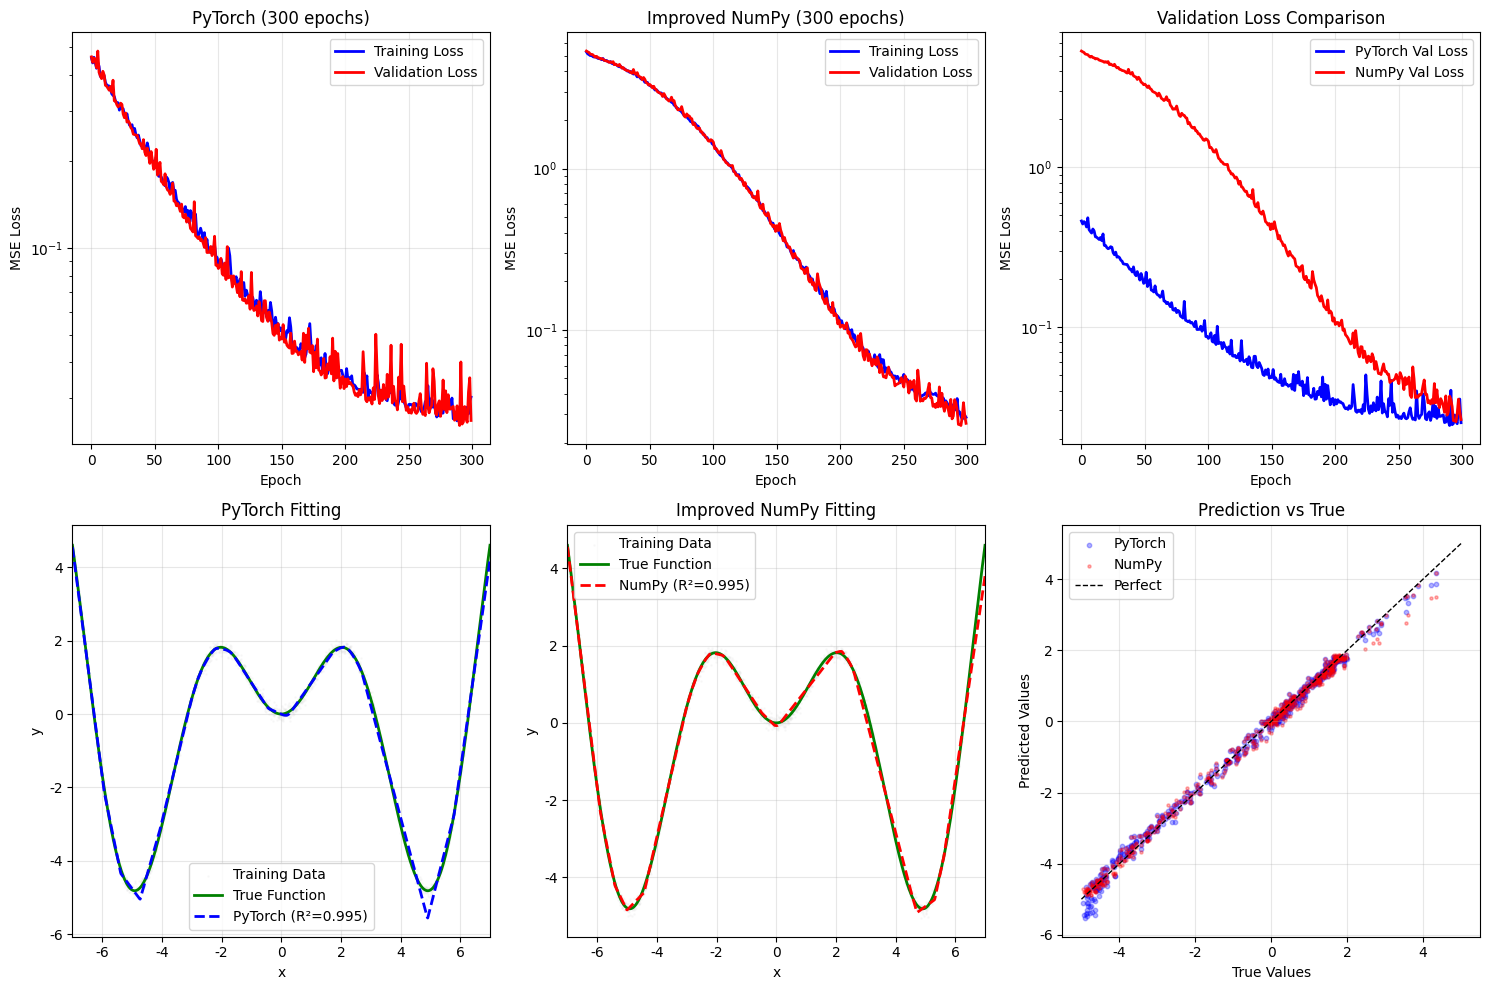

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 子图1：PyTorch训练曲线
axes[0, 0].plot(train_losses_pytorch, label='Training Loss', linewidth=2, color='blue')
axes[0, 0].plot(val_losses_pytorch, label='Validation Loss', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('PyTorch (300 epochs)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# 子图2：NumPy训练曲线
axes[0, 1].plot(train_losses_improved, label='Training Loss', linewidth=2, color='blue')
axes[0, 1].plot(val_losses_improved, label='Validation Loss', linewidth=2, color='red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE Loss')
axes[0, 1].set_title('Improved NumPy (300 epochs)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_yscale('log')

# 子图3：损失对比
axes[0, 2].plot(val_losses_pytorch, label='PyTorch Val Loss', linewidth=2, color='blue')
axes[0, 2].plot(val_losses_improved, label='NumPy Val Loss', linewidth=2, color='red')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('MSE Loss')
axes[0, 2].set_title('Validation Loss Comparison')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_yscale('log')

# 子图4：PyTorch拟合效果
x_eval = np.linspace(-7, 7, 1000).reshape(-1, 1)
y_eval_true = target_function(x_eval)
x_eval_tensor = torch.FloatTensor(x_eval).to(device)
with torch.no_grad():
    y_eval_pytorch = pytorch_model(x_eval_tensor).cpu().numpy()

axes[1, 0].scatter(X_train, y_train, alpha=0.1, s=1, c='lightgray', label='Training Data')
axes[1, 0].plot(x_eval, y_eval_true, 'g-', linewidth=2, label='True Function')
axes[1, 0].plot(x_eval, y_eval_pytorch, 'b--', linewidth=2, 
                label=f'PyTorch (R²={r2_pytorch:.3f})')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
axes[1, 0].set_title('PyTorch Fitting')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(-7, 7)

# 子图5：NumPy拟合效果
x_eval_numpy = np.linspace(-7, 7, 1000).reshape(-1, 1)
y_eval_improved = improved_numpy_model.forward(x_eval_numpy)

axes[1, 1].scatter(X_train, y_train, alpha=0.1, s=1, c='lightgray', label='Training Data')
axes[1, 1].plot(x_eval_numpy, y_eval_true, 'g-', linewidth=2, label='True Function')
axes[1, 1].plot(x_eval_numpy, y_eval_improved, 'r--', linewidth=2, 
                label=f'NumPy (R²={r2_improved:.3f})')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')
axes[1, 1].set_title('Improved NumPy Fitting')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(-7, 7)

# 子图6：预测vs真实值对比
axes[1, 2].scatter(y_test, y_pred_pytorch, alpha=0.3, c='blue', s=10, label='PyTorch')
axes[1, 2].scatter(y_test, y_pred_improved, alpha=0.3, c='red', s=5, label='NumPy')
axes[1, 2].plot([-5, 5], [-5, 5], 'k--', linewidth=1, label='Perfect')
axes[1, 2].set_xlabel('True Values')
axes[1, 2].set_ylabel('Predicted Values')
axes[1, 2].set_title('Prediction vs True')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [25]:
print(f"{'模型':<25} {'测试集MSE':<15} {'R²分数':<10} {'最佳验证损失':<15}")
print("-"*70)
print(f"{'PyTorch (Adam)':<25} {test_loss:<15.6f} {r2_pytorch:<10.4f} {best_val_loss:<15.6f}")
print(f"{'NumPy (Adam)':<25} {test_loss_improved:<15.6f} {r2_improved:<10.4f} {best_val_loss_improved:<15.6f}")


模型                        测试集MSE          R²分数       最佳验证损失         
----------------------------------------------------------------------
PyTorch (Adam)            0.025874        0.9951     0.024148       
NumPy (Adam)              0.025027        0.9954     0.025499       
